In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Sentinelnet/KDDTest+.txt", header=None)

# Define all 43 columns (41 features + 1 label + 1 difficulty_level)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty_level"
]

# Assign column names
df.columns = columns

# Preview
print(df.shape)   # should be (22544, 43) for KDDTest+
print(df.head())


(22544, 43)
   duration protocol_type   service  flag  src_bytes  dst_bytes  land  \
0         0           tcp   private   REJ          0          0     0   
1         0           tcp   private   REJ          0          0     0   
2         2           tcp  ftp_data    SF      12983          0     0   
3         0          icmp     eco_i    SF         20          0     0   
4         1           tcp    telnet  RSTO          0         15     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.04   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.61   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    0.31   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.06                         0.00   
1                    0.06                         0.00

In [2]:
df.head()

,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21


['neptune' 'normal' 'saint' 'mscan' 'guess_passwd' 'smurf' 'apache2'
 'satan' 'buffer_overflow' 'back' 'warezmaster' 'snmpgetattack'
 'processtable' 'pod' 'httptunnel' 'nmap' 'ps' 'snmpguess' 'ipsweep'
 'mailbomb' 'portsweep' 'multihop' 'named' 'sendmail' 'loadmodule' 'xterm'
 'worm' 'teardrop' 'rootkit' 'xlock' 'perl' 'land' 'xsnoop' 'sqlattack'
 'ftp_write' 'imap' 'udpstorm' 'phf']
attack_category
Normal    9711
DoS       5741
R2L       2199
Probe     1106
U2R         37
Name: count, dtype: int64


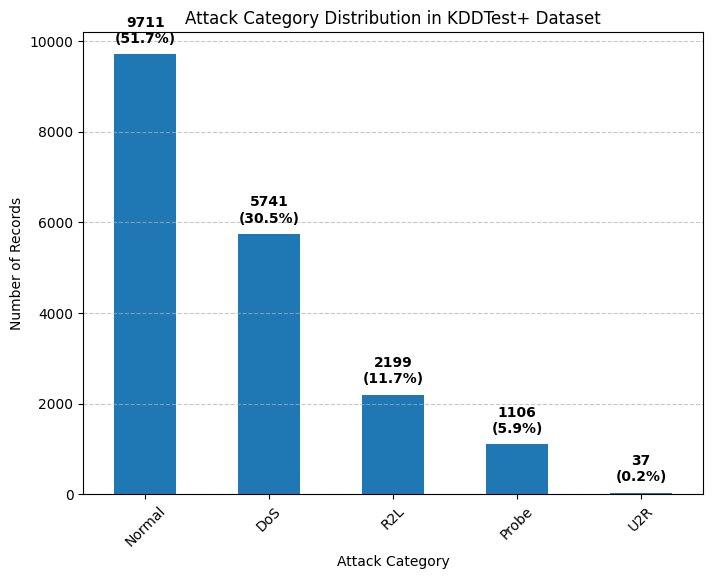

In [8]:
# First check unique labels
print(df['label'].unique())

# Map fine-grained labels into attack categories
attack_map = {
    # DoS
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS',
    'pod': 'DoS', 'land': 'DoS',

    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',

    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L',

    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',

    # Normal
    'normal': 'Normal'
}

# Create new column for high-level attack category
df['attack_category'] = df['label'].map(attack_map)

# Summarize counts
print(df['attack_category'].value_counts())
import matplotlib.pyplot as plt

# Count distribution
attack_counts = df['attack_category'].value_counts()
total = attack_counts.sum()

# Plot bar chart
plt.figure(figsize=(8,6))
bars = attack_counts.plot(kind='bar')

plt.title("Attack Category Distribution in KDDTest+ Dataset")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels (count + percentage) on top of each bar
for i, count in enumerate(attack_counts):
    percent = (count / total) * 100
    plt.text(i, count + (0.01 * total), f"{count}\n({percent:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


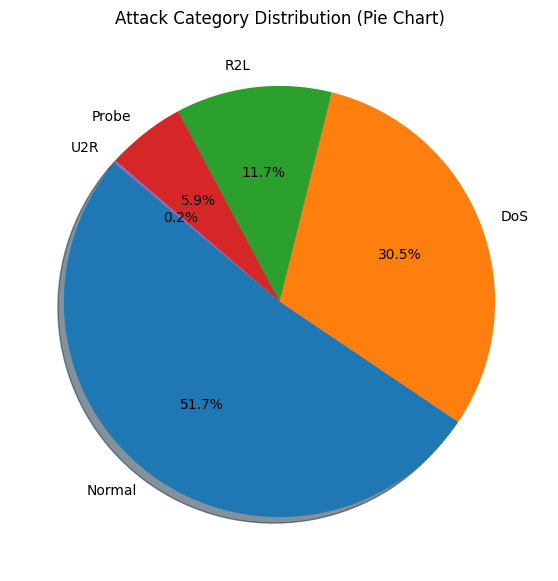

In [9]:
# Pie chart of attack categories
attack_counts = df['attack_category'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    attack_counts,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.title("Attack Category Distribution (Pie Chart)")
plt.show()


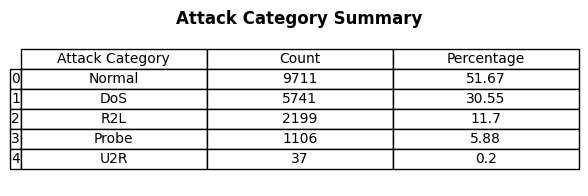

  Attack Category  Count  Percentage
0          Normal   9711       51.67
1             DoS   5741       30.55
2             R2L   2199       11.70
3           Probe   1106        5.88
4             U2R     37        0.20


In [10]:
# Create summary table with counts and percentages
summary_table = pd.DataFrame({
    "Attack Category": attack_counts.index,
    "Count": attack_counts.values,
    "Percentage": (attack_counts.values / total * 100).round(2)
})

# Display neatly
import matplotlib.pyplot as plt
from pandas.plotting import table

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')
tbl = table(ax, summary_table, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title("Attack Category Summary", fontsize=12, fontweight='bold')
plt.show()

# Also print table in plain text
print(summary_table)


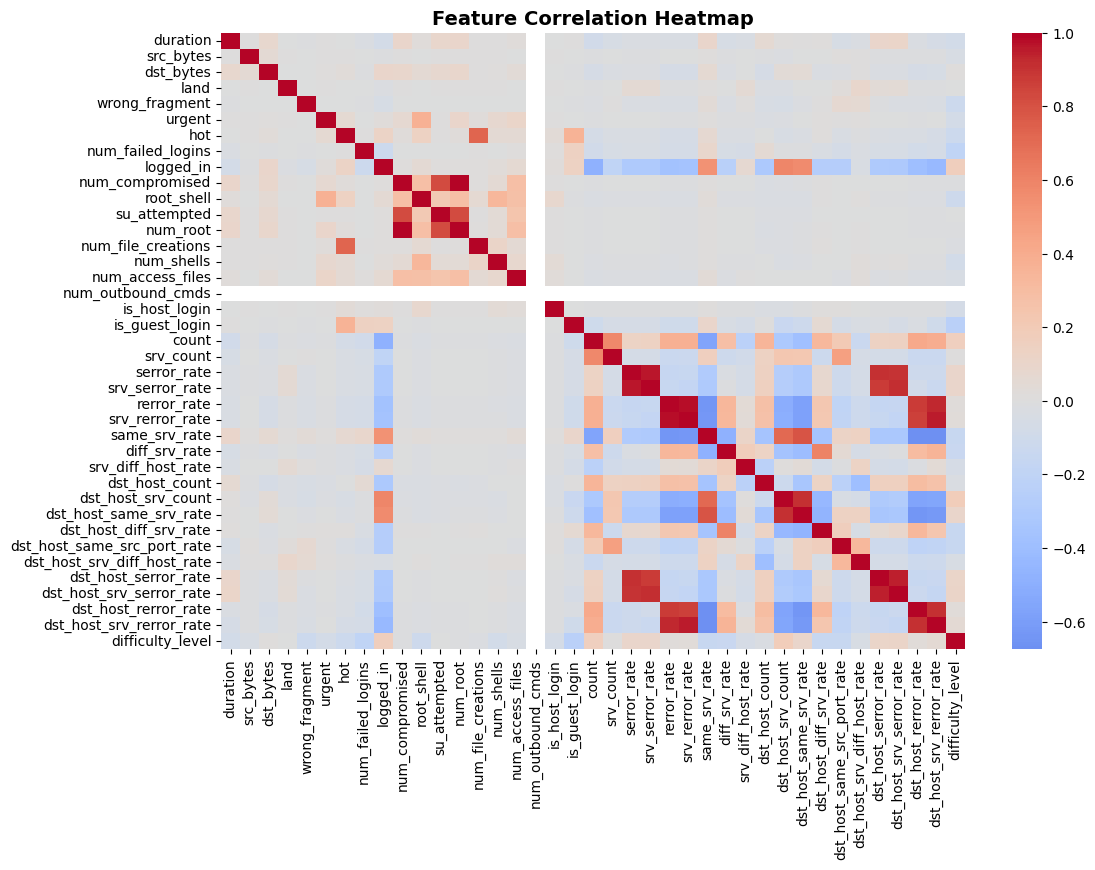

In [11]:
import seaborn as sns

# Select only numeric features
numeric_df = df.select_dtypes(include=['int64','float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, cbar=True)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()


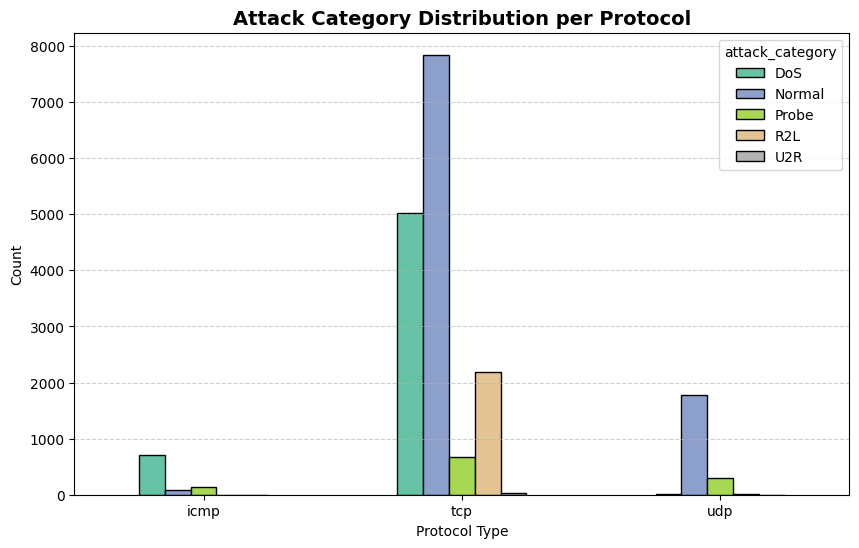

attack_category   DoS  Normal  Probe   R2L  U2R
protocol_type                                  
icmp              706      93    142     1    0
tcp              5023    7842    665  2190   37
udp                12    1776    299     8    0


In [12]:
protocol_attack = pd.crosstab(df['protocol_type'], df['attack_category'])

protocol_attack.plot(kind="bar", figsize=(10,6), colormap="Set2", edgecolor="black")
plt.title("Attack Category Distribution per Protocol", fontsize=14, fontweight='bold')
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(protocol_attack)


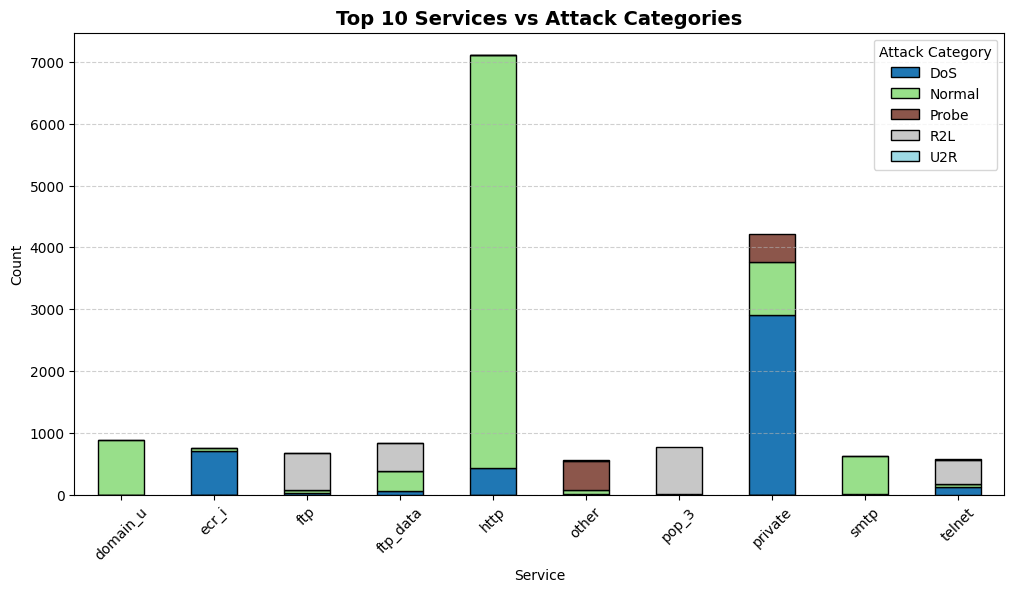

In [13]:
# Top 10 services
top_services = df['service'].value_counts().head(10).index
service_attack = pd.crosstab(df[df['service'].isin(top_services)]['service'],
                             df['attack_category'])

service_attack.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20", edgecolor="black")
plt.title("Top 10 Services vs Attack Categories", fontsize=14, fontweight='bold')
plt.xlabel("Service")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Attack Category")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


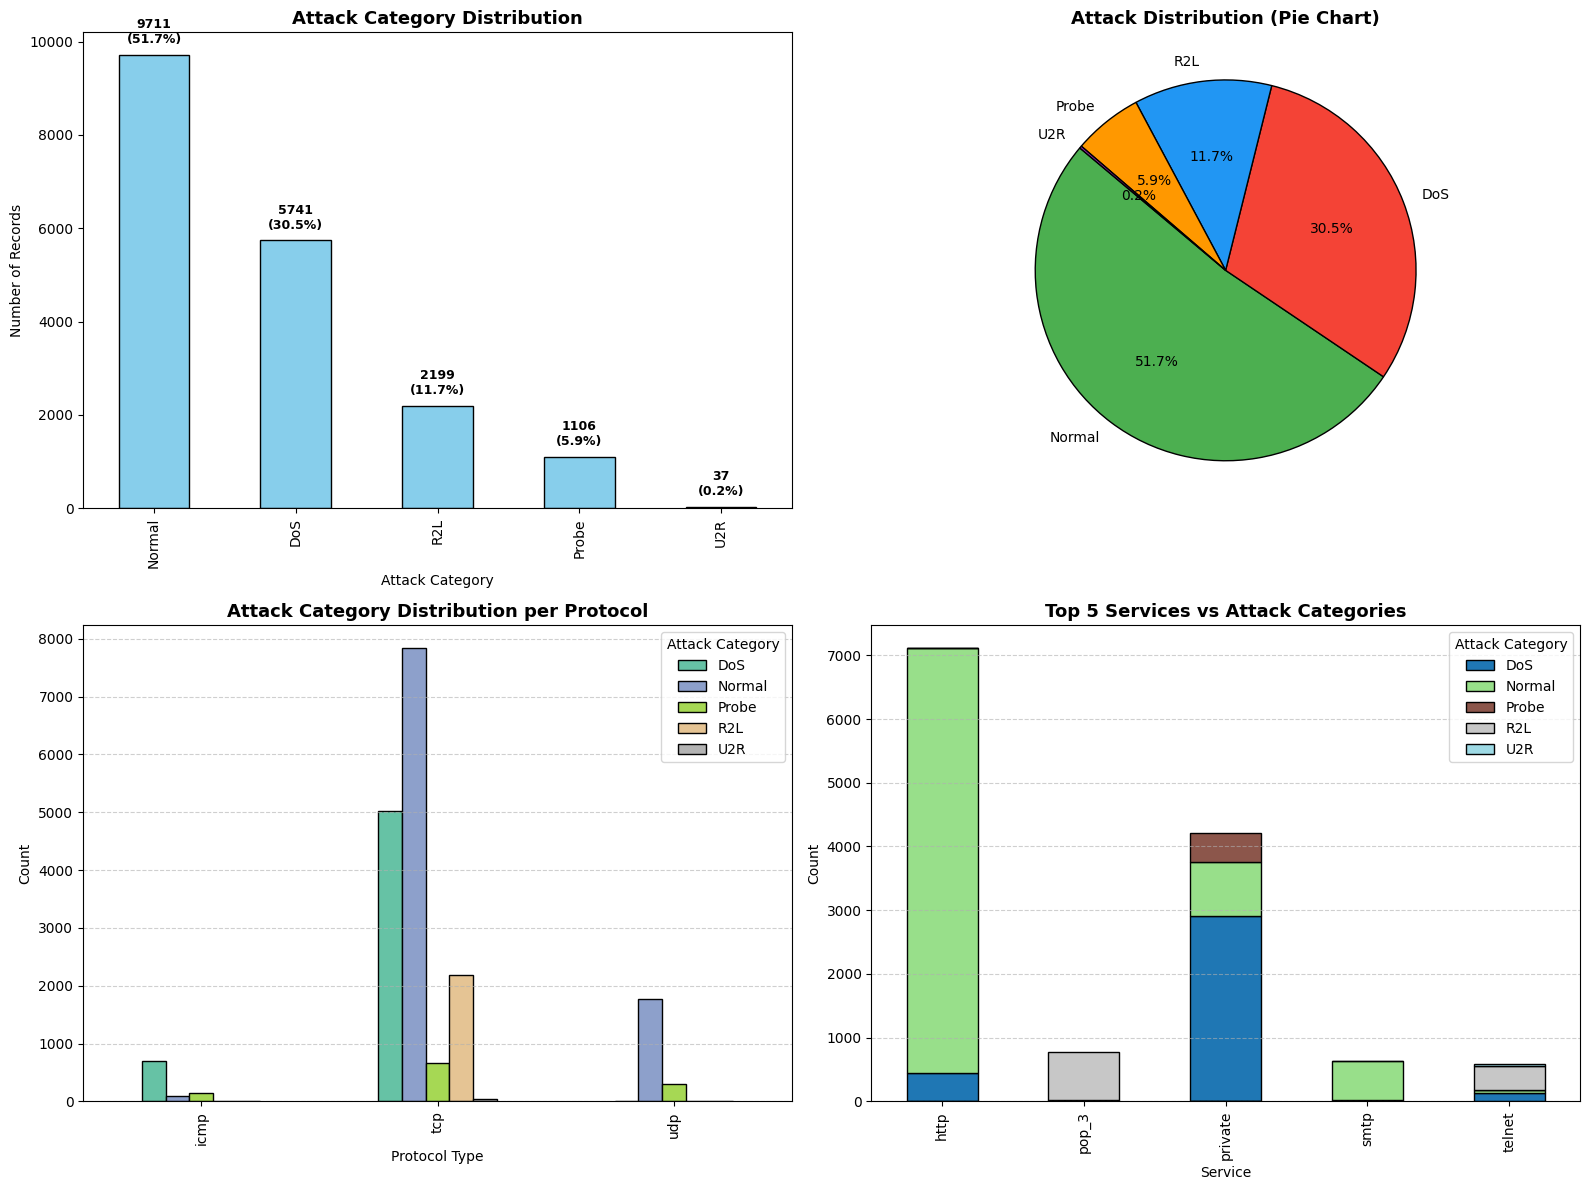

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Attack Category Distribution ---
attack_counts = df['attack_category'].value_counts()
total = attack_counts.sum()

# --- 2. Protocol vs Attack ---
protocol_attack = pd.crosstab(df['protocol_type'], df['attack_category'])

# --- 3. Service vs Attack (Top 5 services for clarity) ---
top_services = df['service'].value_counts().head(5).index
service_attack = pd.crosstab(df[df['service'].isin(top_services)]['service'],
                             df['attack_category'])

# --- Dashboard with multiple subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar chart
bars = attack_counts.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title("Attack Category Distribution", fontsize=13, fontweight='bold')
axes[0,0].set_xlabel("Attack Category")
axes[0,0].set_ylabel("Number of Records")
for i, count in enumerate(attack_counts):
    percent = (count / total) * 100
    axes[0,0].text(i, count + (0.01 * total), f"{count}\n({percent:.1f}%)",
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
axes[0,1].pie(
    attack_counts,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4CAF50','#F44336','#2196F3','#FF9800','#9C27B0'],
    wedgeprops={"edgecolor":"black","linewidth":1}
)
axes[0,1].set_title("Attack Distribution (Pie Chart)", fontsize=13, fontweight='bold')

# Protocol vs Attack
protocol_attack.plot(kind="bar", ax=axes[1,0], colormap="Set2", edgecolor="black")
axes[1,0].set_title("Attack Category Distribution per Protocol", fontsize=13, fontweight='bold')
axes[1,0].set_xlabel("Protocol Type")
axes[1,0].set_ylabel("Count")
axes[1,0].legend(title="Attack Category")
axes[1,0].grid(axis='y', linestyle='--', alpha=0.6)

# Service vs Attack (stacked bar)
service_attack.plot(kind="bar", stacked=True, ax=axes[1,1], colormap="tab20", edgecolor="black")
axes[1,1].set_title("Top 5 Services vs Attack Categories", fontsize=13, fontweight='bold')
axes[1,1].set_xlabel("Service")
axes[1,1].set_ylabel("Count")
axes[1,1].legend(title="Attack Category")
axes[1,1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
